# Loading the data

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
# from ..dm_tools import data_prep

df = pd.read_csv("../data/clean_group_data.csv")

rs = 42 # reusing from data_partition for consistency

# train test split
y = df['is_canceled']
X = df.drop(columns=["is_canceled"])
X_mat = X.values


X_train, X_test, y_train, y_test = train_test_split(
    X_mat,
    y,
    test_size=0.3,
    random_state=rs,
    stratify=y
)

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

print("------ Before scaling ------")
for i in range(5):
    col = X_train[:, i]
    print("Variable #{}: min {}, max {}, mean {:.2f} and std dev {:.2f}"
          .format(i, min(col), max(col), np.mean(col), np.std(col))
          )

# learn the mean and std dev, then use them to scale the training data
X_train = scaler.fit_transform(X_train, y_train)
X_test = scaler.transform(X_test)

print("------ After scaling ------")
for i in range(5):
    col = X_train[:, i]
    print("Variable #{}: min {}, max {}, mean {:.2f} and std dev {:.2f}"
          .format(i, min(col), max(col), np.mean(col), np.std(col))
          )

------ Before scaling ------
Variable #0: min 0, max 629, mean 110.73 and std dev 111.73
Variable #1: min 1, max 53, mean 27.23 and std dev 13.38
Variable #2: min 1, max 31, mean 15.84 and std dev 8.76
Variable #3: min 0, max 9, mean 0.79 and std dev 0.88
Variable #4: min 0, max 25, mean 2.18 and std dev 1.44
------ After scaling ------
Variable #0: min -0.9909919193066413, max 4.6385038657554585, mean 0.00 and std dev 1.00
Variable #1: min -1.9596432568793416, max 1.9254561929559655, mean -0.00 and std dev 1.00
Variable #2: min -1.693951114439317, max 1.7308149154555466, mean 0.00 and std dev 1.00
Variable #3: min -0.8967150310873377, max 9.358856154777953, mean -0.00 and std dev 1.00
Variable #4: min -1.5145630067234355, max 15.832275768764069, mean 0.00 and std dev 1.00


In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=rs)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [5]:
from sklearn.metrics import classification_report

# training and test accuracy
print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))

# classification report on test data
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

Train accuracy: 0.7734848484848484
Test accuracy: 0.7669023420238621
              precision    recall  f1-score   support

           0       0.78      0.84      0.81      2635
           1       0.75      0.66      0.70      1891

    accuracy                           0.77      4526
   macro avg       0.76      0.75      0.76      4526
weighted avg       0.77      0.77      0.76      4526



In [6]:
feature_names = X.columns
coef = model.coef_[0]

indices = np.argsort(np.absolute(coef))
indices = np.flip(indices, axis=0)
indices = indices[:20]

for i in indices:
    print(feature_names[i], ':', coef[i])

lead_time : 0.7453384579155077
total_of_special_requests : -0.6447852857490319
country_PRT : 0.5671084900824487
adr : 0.46964699787033576
booking_changes : -0.40644158598894903
previous_cancellations : 0.37153030651968305
country_DEU : -0.34625606992849844
country_FRA : -0.27133801334092517
country_SRB : -0.2496890555146928
country_ISL : -0.23708479467341295
country_NZL : -0.21604910525653348
stays_in_week_nights : 0.21281294463175776
adults : 0.17762237439344689
country_ARE : 0.17497535893556243
reserved_room_type_7 : -0.1717716273481565
country_IRQ : -0.16547677146542605
country_AUT : -0.15148955341376893
stays_in_weekend_nights : 0.14952476415121058
country_NLD : -0.14140194866365063
country_CHN : 0.12955460926094758


In [7]:
from sklearn.model_selection import GridSearchCV

# grid search cv
params = {'C': [pow(10, x) for x in range(-6, 4)]}

cv = GridSearchCV(param_grid=params, estimator=LogisticRegression(random_state=rs), cv=10, n_jobs=-1)
cv.fit(X_train, y_train)

# training and test accuracy
print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))

# classification report on test data
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# parameters of best model
print(cv.best_params_)

Train accuracy: 0.7734848484848484
Test accuracy: 0.7669023420238621
              precision    recall  f1-score   support

           0       0.78      0.84      0.81      2635
           1       0.75      0.66      0.70      1891

    accuracy                           0.77      4526
   macro avg       0.76      0.75      0.76      4526
weighted avg       0.77      0.77      0.76      4526

{'C': 0.1}


Index(['lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'previous_cancellations', 'booking_changes', 'adr',
       'total_of_special_requests', 'is_canceled'],
      dtype='str')


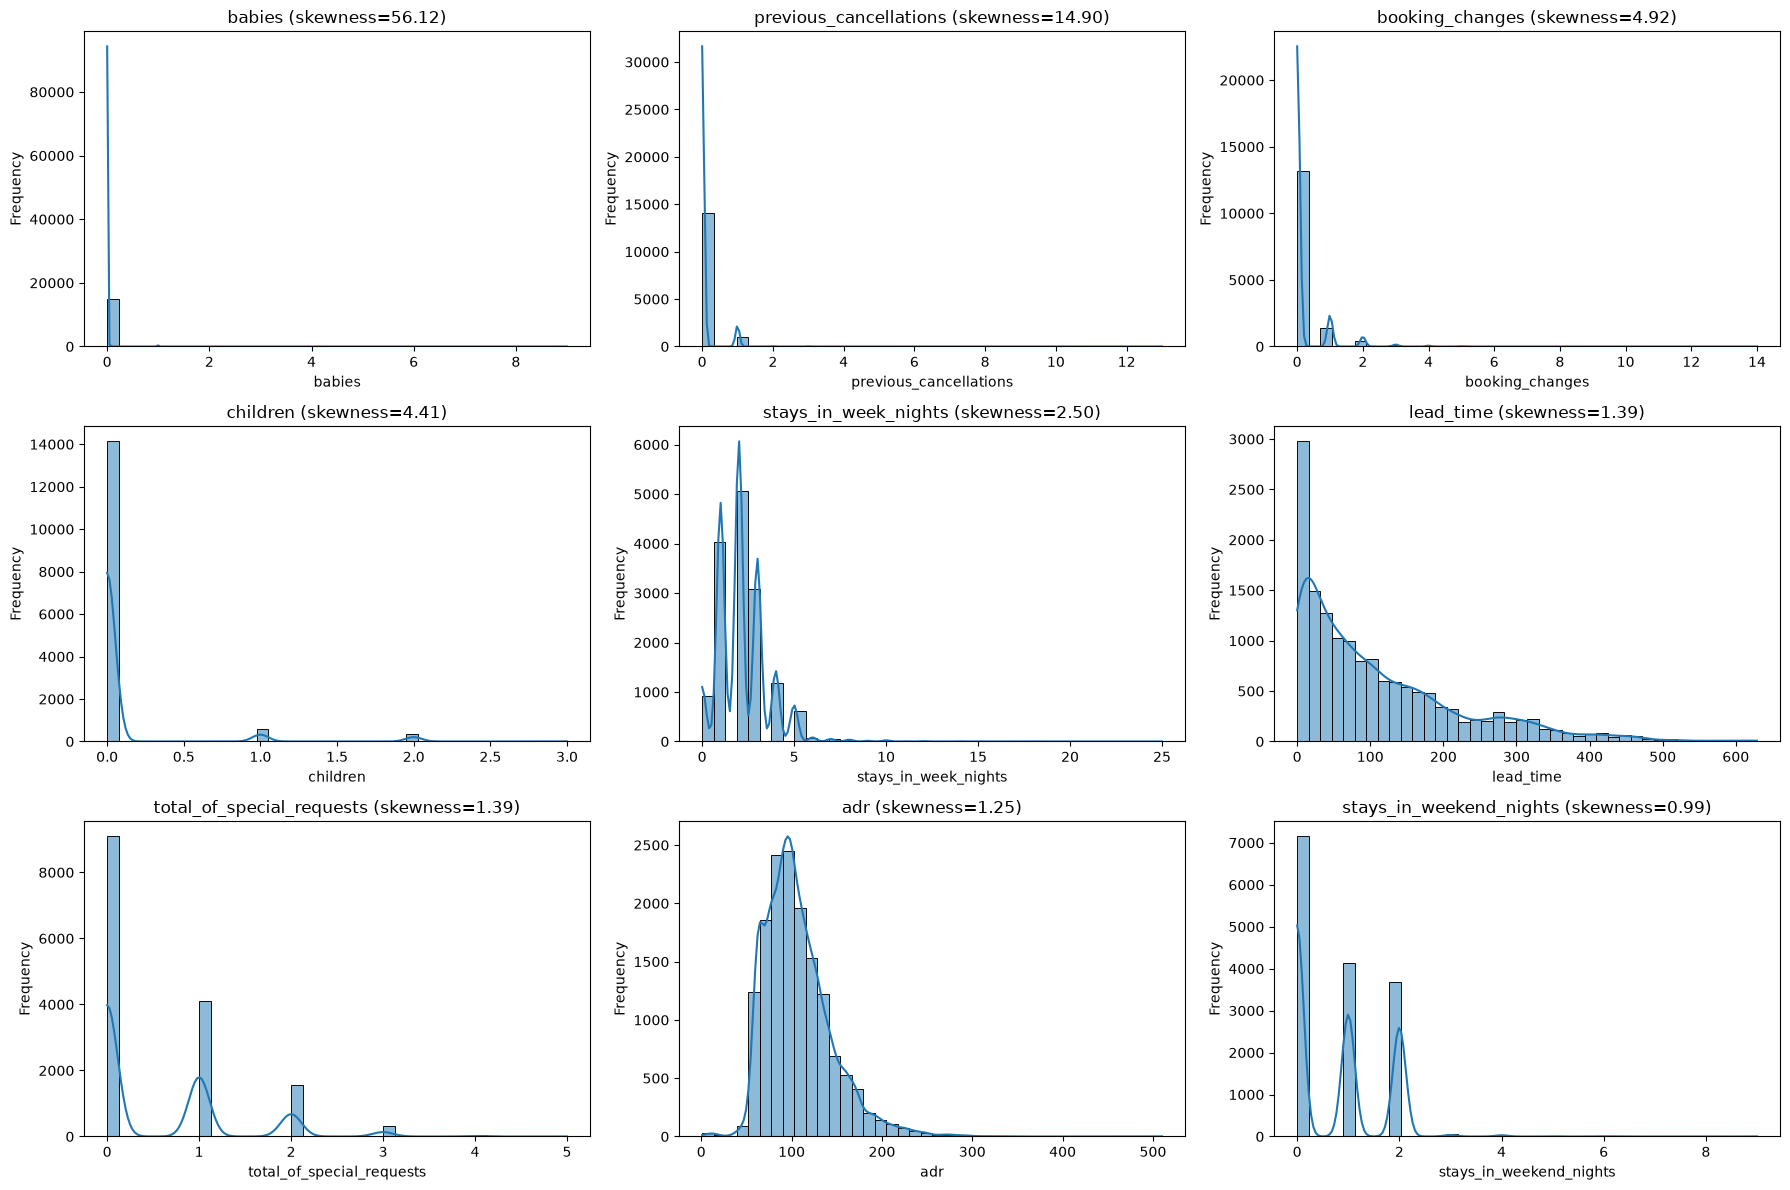

babies                       56.120849
previous_cancellations       14.902801
booking_changes               4.919125
children                      4.411927
stays_in_week_nights          2.504936
lead_time                     1.394264
total_of_special_requests     1.393593
adr                           1.251915
stays_in_weekend_nights       0.992303
dtype: float64

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt


def plot_skewed_columns(df, threshold=1.0, bins=30, columns=3):
    """Plot distributions for numeric columns whose absolute skew exceeds threshold."""
    numeric_df = df.select_dtypes(include=np.number)
    print(numeric_df.columns)
    skewness = numeric_df.skew().sort_values(key=np.abs, ascending=False)
    skewed = skewness[skewness.abs() > threshold]

    if skewed.empty:
        print(f"No numeric columns have absolute skewness greater than {threshold}.")
        return skewed

    rows = int(np.ceil(len(skewed) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(6 * columns, 4 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, column in zip(axes, skewed.index):
        sns.histplot(numeric_df[column].dropna(), bins=bins, kde=True, ax=ax)
        # sns.kdeplot(numeric_df[column].dropna(), ax=ax)
        ax.set_title(f"{column} (skewness={skewed[column]:.2f})")
        ax.set_xlabel(column)
        ax.set_ylabel("Frequency")

    for ax in axes[len(skewed):]:
        ax.remove()

    fig.tight_layout()
    plt.show()
    return skewed

plot_skewed_columns(df, threshold=0.5, bins=40)


In [29]:
def plot_columns(df, data_cols, plot_columns: int = 3, bins=30):
    rows = int(np.ceil(len(data_cols) / plot_columns))
    fig, axes = plt.subplots(rows, plot_columns, figsize=(6 * plot_columns, 4 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, column in zip(axes, data_cols):
        # sns.histplot(df[column].dropna(), bins=bins, kde=True, ax=ax)
        sns.kdeplot(df[column].dropna(), ax=ax)
        ax.set_title(f"{column} (skewness={df[column].skew():.2f})")
        ax.set_xlabel(column)
        ax.set_ylabel("Frequency")

    for ax in axes[len(data_cols):]: # This removes the extra plots created
        ax.remove()

    fig.tight_layout()
    plt.show()

Log-transformed columns: ['babies', 'previous_cancellations', 'booking_changes', 'children', 'stays_in_week_nights', 'lead_time', 'total_of_special_requests', 'adr']
Index(['lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'previous_cancellations', 'booking_changes', 'adr',
       'total_of_special_requests', 'is_canceled'],
      dtype='str')


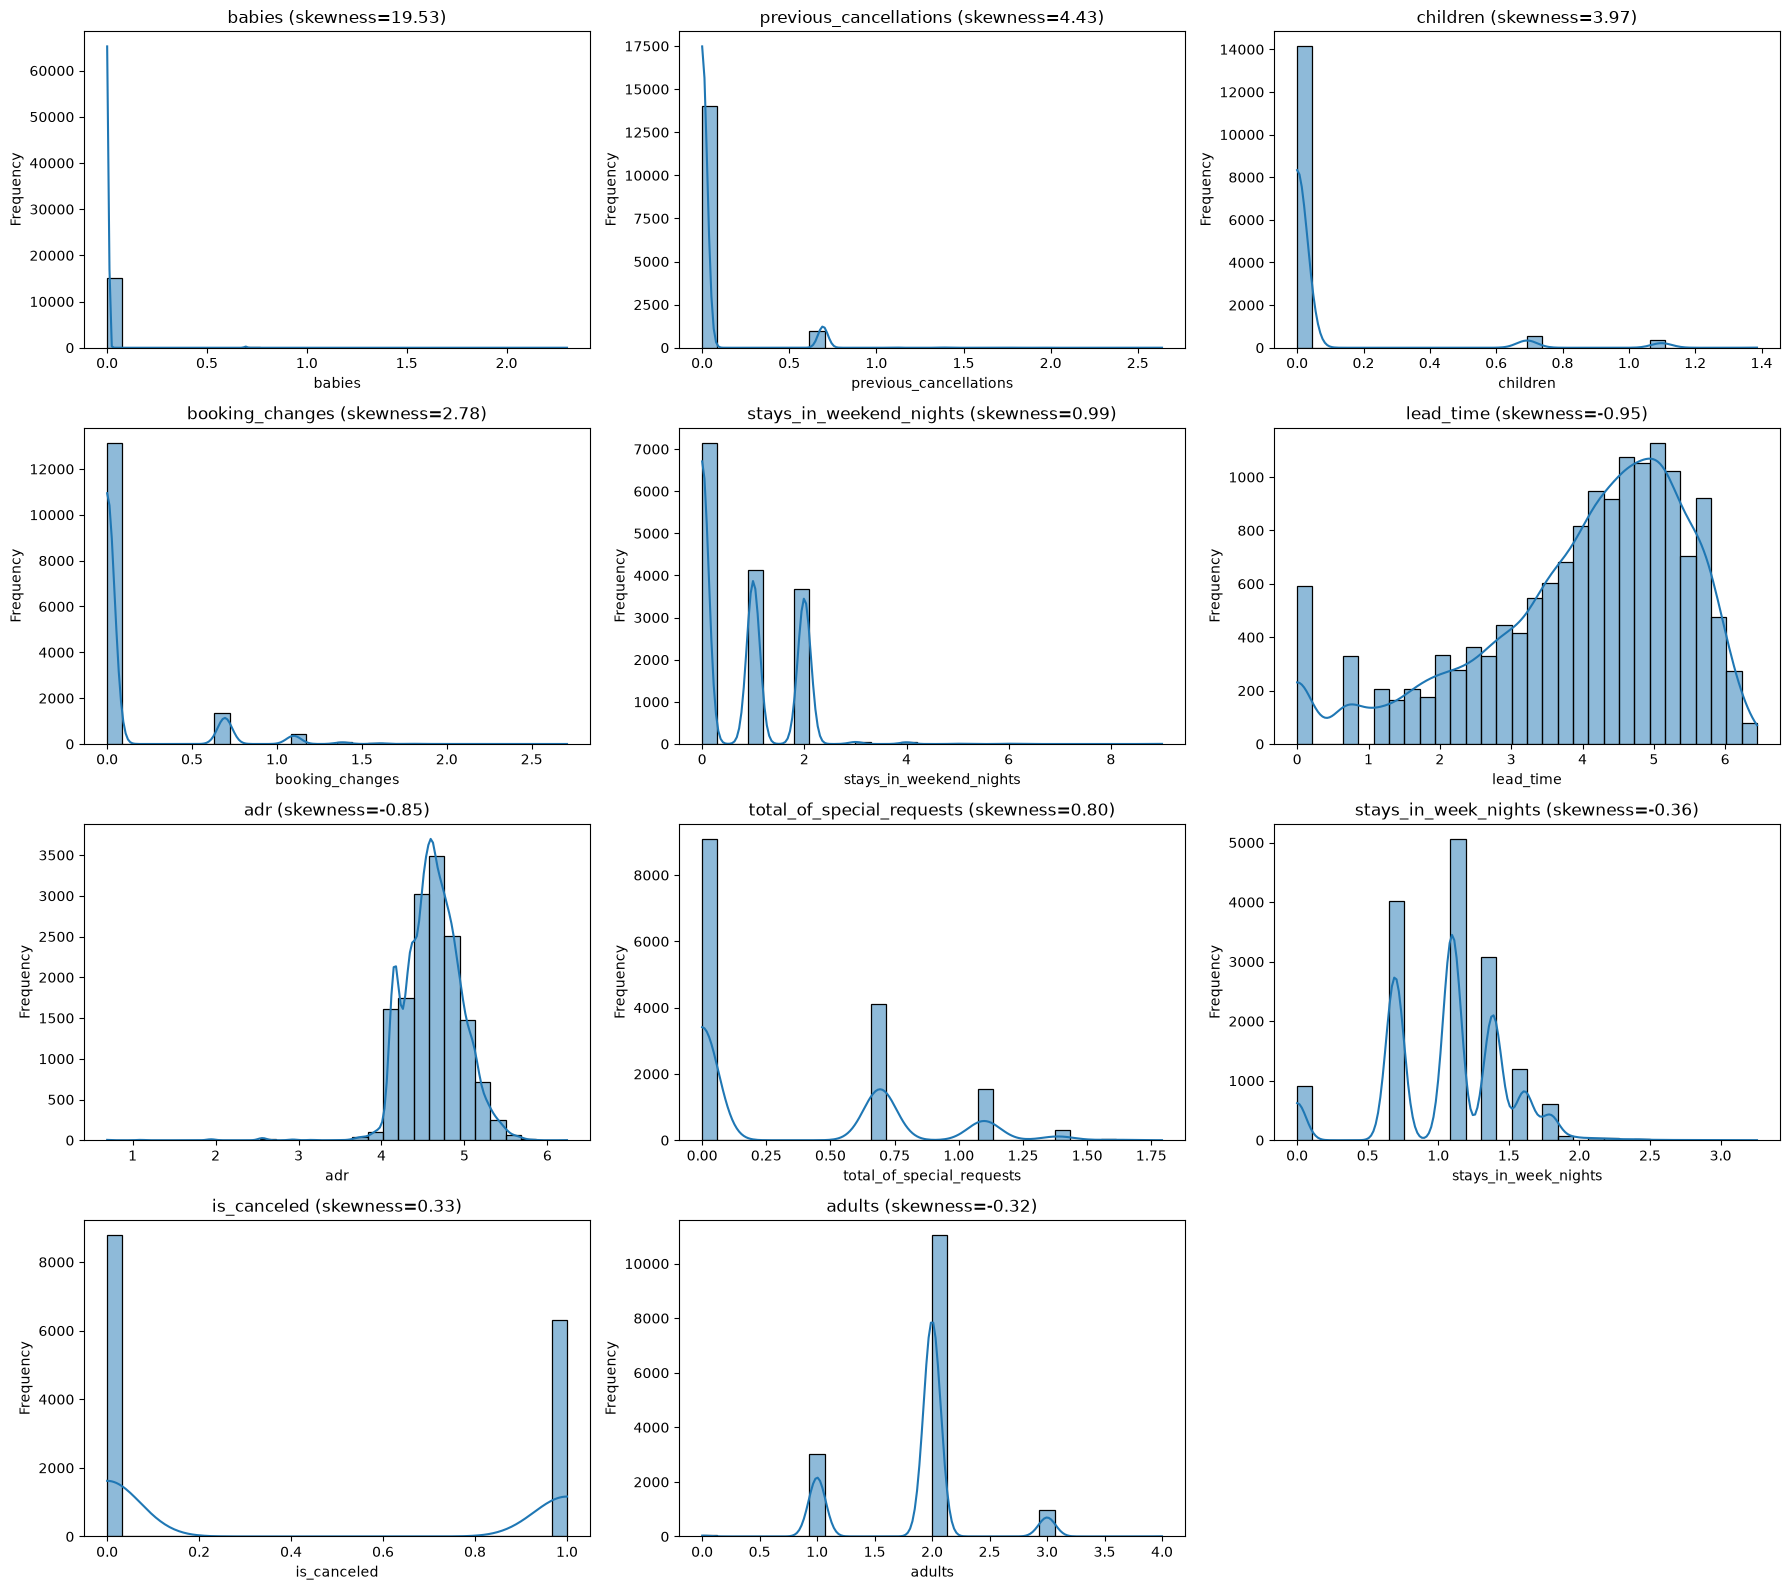

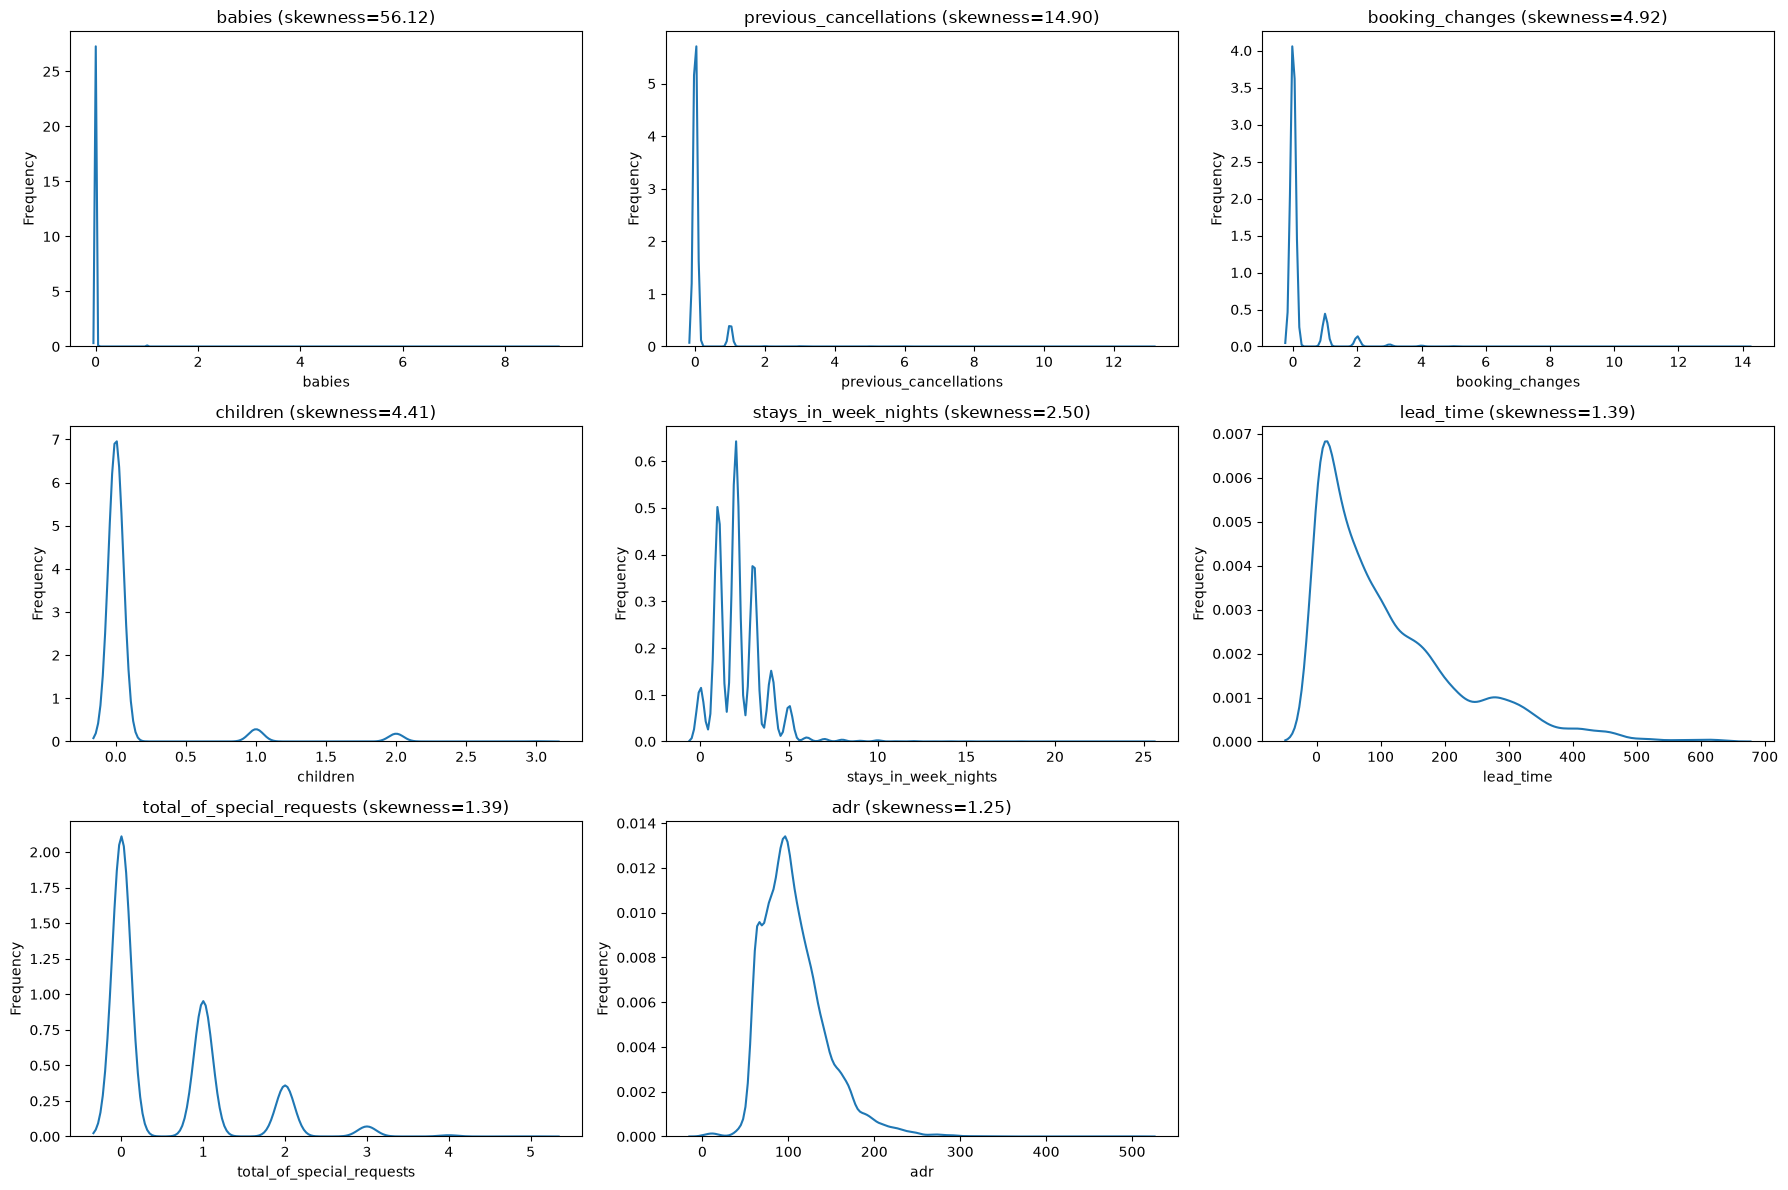

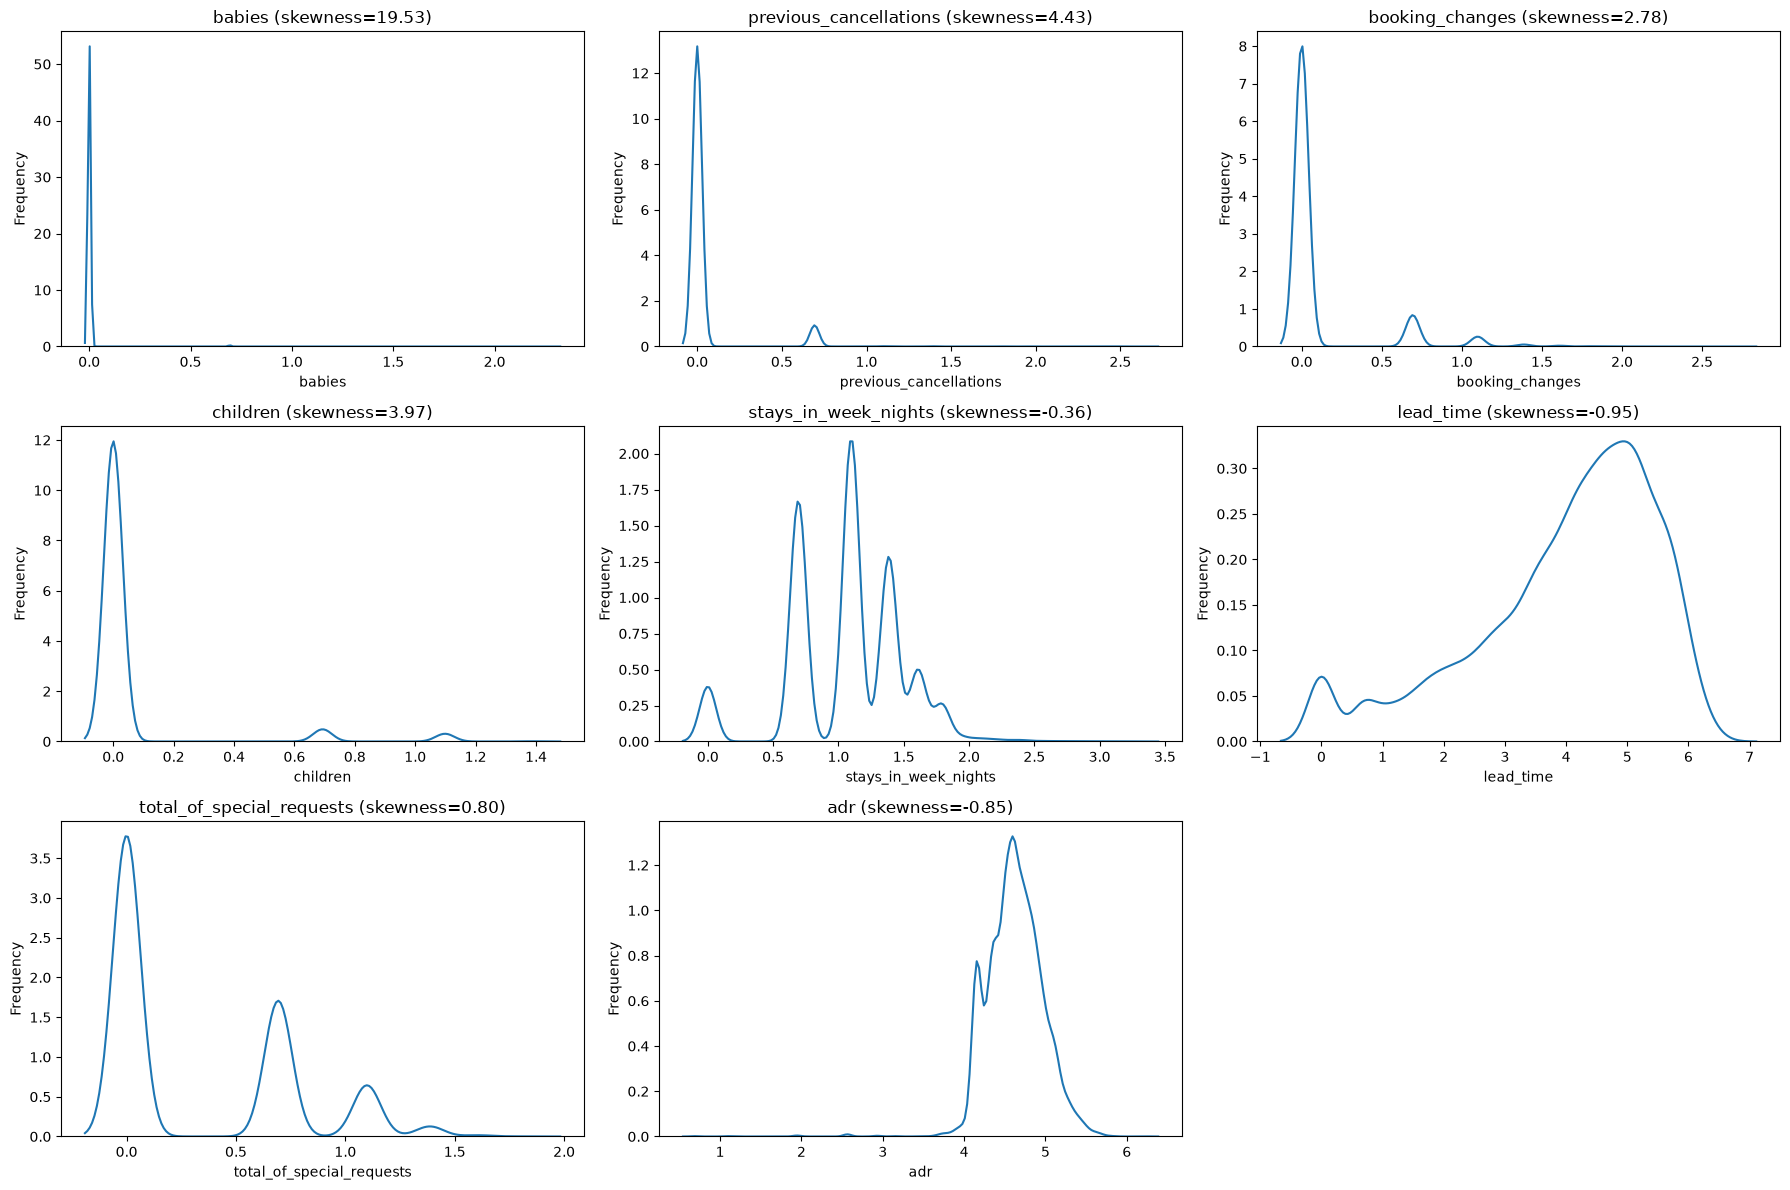

In [31]:
df_log = df.copy()
feature_df = df_log.drop(columns=["is_canceled"])
numeric_features = feature_df.select_dtypes(include=np.number)
skewed_cols = ["babies", "previous_cancellations", "booking_changes", "children", "stays_in_week_nights", "lead_time", "total_of_special_requests", "adr"]
df_log[skewed_cols] = df_log[skewed_cols].apply(lambda x: x+1)
df_log[skewed_cols] = df_log[skewed_cols].apply(np.log)
print("Log-transformed columns:", skewed_cols)
plot_skewed_columns(df_log, threshold=0.2)
plot_columns(df, skewed_cols)
plot_columns(df_log, skewed_cols)

In [32]:
# create X, y and train test data partitions
y_log = df_log['is_canceled']
X_log = df_log.drop(['is_canceled'], axis=1)
X_mat_log = X_log.values
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_mat_log, y_log, test_size=0.3, stratify=y_log, random_state=rs)

# standardise them again
scaler_log = StandardScaler()
X_train_log = scaler_log.fit_transform(X_train_log, y_train_log)
X_test_log = scaler_log.transform(X_test_log)

# grid search CV
params = {'C': [pow(10, x) for x in range(-6, 4)]}

cv = GridSearchCV(param_grid=params, estimator=LogisticRegression(random_state=rs), cv=10, n_jobs=-1)
cv.fit(X_train_log, y_train_log)

# test the best model
print("Train accuracy:", cv.score(X_train_log, y_train_log))
print("Test accuracy:", cv.score(X_test_log, y_test_log))

y_pred = cv.predict(X_test_log)
print(classification_report(y_test_log, y_pred))

# print parameters of the best model
print(cv.best_params_)

Train accuracy: 0.7865530303030303
Test accuracy: 0.7841361025187804
              precision    recall  f1-score   support

           0       0.79      0.85      0.82      2635
           1       0.77      0.69      0.73      1891

    accuracy                           0.78      4526
   macro avg       0.78      0.77      0.77      4526
weighted avg       0.78      0.78      0.78      4526

{'C': 0.1}


In [33]:
from sklearn.feature_selection import RFECV

rfe = RFECV(estimator=LogisticRegression(random_state=rs), cv=10)
rfe.fit(X_train, y_train)

# compare number of variables
print("Original feature set", X_train.shape[1])
print("Number of features after elimination", rfe.n_features_)

Original feature set 160
Number of features after elimination 61


In [37]:
X_train_sel = rfe.transform(X_train)
X_test_sel = rfe.transform(X_test)

# grid search CV
params = {'C': [pow(10, x) for x in range(-6, 4)]}

cv = GridSearchCV(param_grid=params, estimator=LogisticRegression(random_state=rs), cv=10, n_jobs=-1)
cv.fit(X_train_sel, y_train)

# test the best model
print("Train accuracy:", cv.score(X_train_sel, y_train))
print("Test accuracy:", cv.score(X_test_sel, y_test))

y_pred = cv.predict(X_test_sel)
print(classification_report(y_test, y_pred))

# print parameters of the best model
print(cv.best_params_)

Train accuracy: 0.7739583333333333
Test accuracy: 0.7706584180291648
              precision    recall  f1-score   support

           0       0.77      0.86      0.81      2635
           1       0.76      0.65      0.70      1891

    accuracy                           0.77      4526
   macro avg       0.77      0.75      0.76      4526
weighted avg       0.77      0.77      0.77      4526

{'C': 0.01}


slightly worse

In [38]:
# RFE + log transform
rfe = RFECV(estimator=LogisticRegression(random_state=rs), cv=10)
rfe.fit(X_train_log, y_train_log)

# compare number of variables
print("Original feature set", X_train.shape[1])
print("Number of features after elimination", rfe.n_features_)

Original feature set 160
Number of features after elimination 47


In [39]:
X_train_sel_log = rfe.transform(X_train_log)
X_test_sel_log = rfe.transform(X_test_log)

# grid search CV
params = {'C': [pow(10, x) for x in range(-6, 4)]}

cv = GridSearchCV(param_grid=params, estimator=LogisticRegression(random_state=rs), cv=10, n_jobs=-1)
cv.fit(X_train_sel_log, y_train_log)

# test the best model
print("Train accuracy:", cv.score(X_train_sel_log, y_train_log))
print("Test accuracy:", cv.score(X_test_sel_log, y_test_log))

y_pred_log = cv.predict(X_test_sel_log)
print(classification_report(y_test_log, y_pred_log))

# parameters of best model
print(cv.best_params_)

Train accuracy: 0.7850378787878788
Test accuracy: 0.7850198851082634
              precision    recall  f1-score   support

           0       0.79      0.86      0.82      2635
           1       0.78      0.68      0.73      1891

    accuracy                           0.79      4526
   macro avg       0.78      0.77      0.77      4526
weighted avg       0.78      0.79      0.78      4526

{'C': 0.01}


improved test accuracy! precision, recall, f1-score all maintain the same scores as the original log model and some even out-perform it!!!

# Using select from model instead

In [40]:
from sklearn.tree import DecisionTreeClassifier

params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': range(2, 7),
    'min_samples_leaf': range(20, 60, 10)
}

cv = GridSearchCV(param_grid=params, estimator=DecisionTreeClassifier(random_state=rs), cv=10)
cv.fit(X_train_log, y_train_log)

print(cv.best_params_)

{'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 30}


In [41]:
def analyse_feature_importance(dm_model, feature_names, n_to_display=20):
    importances = dm_model.feature_importances_

    indices = np.argsort(importances)
    indices = np.flip(indices, axis=0)

    indices = indices[:n_to_display]

    for i in indices:
        print(feature_names[i], ':', importances[i])

In [42]:
analyse_feature_importance(cv.best_estimator_, X_log.columns)

country_PRT : 0.3804138310978659
lead_time : 0.2795897058007289
total_of_special_requests : 0.12174104404933711
adr : 0.0838746828358046
booking_changes : 0.060236210209171914
previous_cancellations : 0.027615430854073794
arrival_date_week_number : 0.018146825320547354
country_DEU : 0.008440817357714004
adults : 0.005248469120982105
country_CHN : 0.003971711138828889
stays_in_weekend_nights : 0.0028456045938597594
stays_in_week_nights : 0.0026388267174561235
arrival_date_day_of_month : 0.0025642497370240067
arrival_date_month_8 : 0.0022039320236181222
reserved_room_type_4 : 0.0004686591429874635
reserved_room_type_Unknown : 0.0
country_TWN : 0.0
country_TUR : 0.0
reserved_room_type_6 : 0.0
reserved_room_type_7 : 0.0


Only 15 features with an importance value more than 0. According to this tuned decision tree, there are only 15 important features in our dataset

In [43]:
from sklearn.feature_selection import SelectFromModel

selectmodel = SelectFromModel(cv.best_estimator_, prefit=True)
X_train_sel_model = selectmodel.transform(X_train_log)
X_test_sel_model = selectmodel.transform(X_test_log)

print(X_train_sel_model.shape)

(10560, 8)


Now there are only 8 left

In [44]:
params = {'C': [pow(10, x) for x in range(-6, 4)]}

cv = GridSearchCV(param_grid=params, estimator=LogisticRegression(random_state=rs), cv=10, n_jobs=-1)
cv.fit(X_train_sel_model, y_train_log)

print("Train accuracy:", cv.score(X_train_sel_model, y_train_log))
print("Test accuracy:", cv.score(X_test_sel_model, y_test_log))

y_pred = cv.predict(X_test_sel_model)
print(classification_report(y_test_log, y_pred))

# params of best model
print(cv.best_params_)

Train accuracy: 0.7663825757575757
Test accuracy: 0.7629253203711887
              precision    recall  f1-score   support

           0       0.76      0.86      0.81      2635
           1       0.76      0.63      0.69      1891

    accuracy                           0.76      4526
   macro avg       0.76      0.74      0.75      4526
weighted avg       0.76      0.76      0.76      4526

{'C': 0.01}
